# The Reservations Nowcast — do diners coming back predict restaurant stocks? 🍽️
### Using an OpenTable-style 'seated-diners' trend to time a restaurant basket, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

Here's an intuitive idea. During the pandemic, OpenTable published a public dashboard of **seated diners** — how many people were being seated at restaurants each day versus 2019. Everyone watched it to see how fast dining was recovering. The natural trade: if diners are flooding back, restaurant revenue should follow, so **restaurant stocks** (and, loosely, the consumer-discretionary ETF **XLY**) should rise. Read this week's reservations trend, position the restaurant basket for next week.

It's a classic **alt-data nowcast** — use a real-world behaviour signal to get ahead of the numbers. So does it work?

> 🍽️ **The honest catch, up front.** There is **no free, clean, historical seated-diners feed** you can download and test on. OpenTable's dashboard was a moving web widget, kept getting restated, and was eventually taken down — and it only covered the pandemic. So we can't check the claim on real data. Instead we build a **synthetic world** where we *know* the answer, and prove our measuring machine works. That's why the Signal stamp is capped at **Weak** (plausible + machinery-proven) and can never be **Real** here.

> 📓 **This is the plain-language layer.** Want the regressions, the *t*-stats and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from opentable_reservations import data, strategy as st

# THERE IS NO REAL TAPE (see data.py): the free seated-diners history does not exist.
REAL = data.fetch_series(fetch=False)
HAVE_REAL = not REAL.empty
print("real seated-diners tape present:", HAVE_REAL, "(synthetic-only study by design)")

# The demonstrator world: a deterministic, seeded synthetic panel with the nowcast PLANTED.
PANEL, TRUTH = data.synthetic_series(nowcast_beta=0.35, seed=555)
print("demonstrator panel:", len(PANEL), "weeks,", PANEL.index[0].date(), "->", PANEL.index[-1].date(),
      "| fp", data.fingerprint(PANEL))


real seated-diners tape present: False (synthetic-only study by design)
demonstrator panel: 312 weeks, 2020-01-05 -> 2025-12-21 | fp 2491c27d3bc8


## The answer first 🎯

| Question | Answer |
|---|---|
| Is 'reservations predict restaurant stocks' a sensible idea? | **Yes** — it's a real, literature-backed alt-data nowcast. Diners returning *should* precede revenue. |
| Does our engine catch the effect when it's really there? | **Yes** — on a world where we *plant* the nowcast, it fires cleanly (predictive *t* **+4.49**), and stays flat when there's nothing (control **−0.01**). The measuring machine is honest. |
| Can we confirm it on real data? | **No** — there is no free, stable seated-diners history to test on. The dashboard was transient and discontinued. |
| So could you trade it? | **No.** No real, license-able, reproducible signal → nothing to trade. The edge you'll see below lives only in the synthetic demo. |

> The idea is good and our tools work — but without a real tape, 'reservations nowcast restaurant stocks' stays a **Weak** (unconfirmed) signal and a **Mirage** trade.

## 1 · The claim

> *"When restaurant reservations recover, restaurant stocks follow — so the reservations trend nowcasts the sector."*

The intuition is clean. Reservations are a **real-time** read on dining demand; company revenue and stock prices react with a lag. If you can see the demand signal first, you're ahead of the market. This is the same logic behind using Google-search trends, satellite parking-lot counts or credit-card panels to nowcast revenue — reservations are a dining-flavoured version.

## 2 · So what?

If it worked and you could get the data, you'd have a genuine edge on restaurant names and XLY. But alt-data edges are famously fragile: they decay once everyone watches the same feed, and — crucially here — they need **clean, historical, point-in-time data** to even test. The whole study hinges on whether that data exists. (Spoiler from Beat 3: it doesn't, for free.)

## 3 · How would we even know?

1. **Build the signal.** Take the reservations year-over-year trend and strip out two things: its own slow drift (we care about *changes*, not the level) and whatever the overall market did that week (so we're not just re-discovering 'stocks went up'). What's left is the **reservations surprise**.
2. **Predict next week.** Does a positive surprise *this* week go with a higher restaurant-basket return *next* week? (We always use this week's info to bet on next week — a one-week lag, no peeking.)
3. **Trade it.** Go long the basket when the surprise is positive, step aside when it's negative, and see if that beats just holding — after trading costs.

The problem: step 1 needs a real seated-diners history, and there isn't a free one. So we run the whole pipeline on a **synthetic world** where we planted a known nowcast, to prove the machine measures correctly.

## 4 · The teardown — let's actually look

**On a world where the nowcast is really there, does a positive reservations surprise this week predict a higher basket return next week?** (Synthetic demonstrator — the nowcast is planted.)

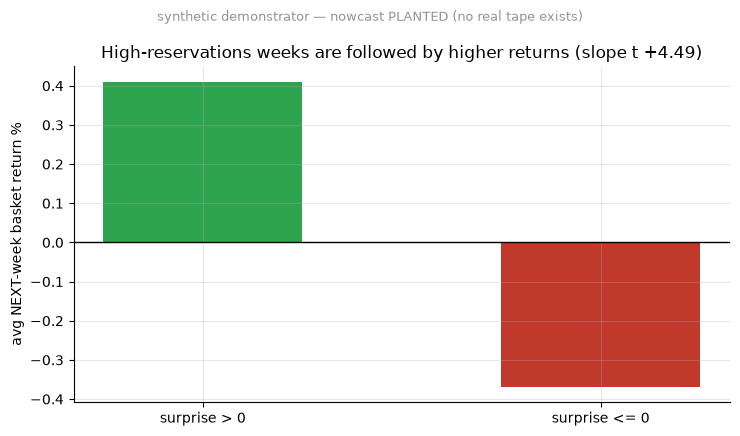

after positive surprise: +0.41%/wk | after negative: -0.37%/wk
predictive slope t (Newey-West) = +4.49


In [2]:
af = st.aligned_frame(PANEL)      # (this-week surprise, next-week return), one-week lag
reg = st.predictive_regression(PANEL)
# bucket next-week returns by the sign of this week's surprise
pos = af[af['signal'] > 0]['fwd_ret'] * 100
neg = af[af['signal'] <= 0]['fwd_ret'] * 100
fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.bar(['surprise > 0','surprise <= 0'], [pos.mean(), neg.mean()], color=[GREEN, RED], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('avg NEXT-week basket return %')
ax.set_title(f'High-reservations weeks are followed by higher returns (slope t {reg["slope_t"]:+.2f})')
fig.suptitle('synthetic demonstrator — nowcast PLANTED (no real tape exists)', fontsize=9, color=GREY)
plt.tight_layout(); plt.show()
print(f'after positive surprise: {pos.mean():+.2f}%/wk | after negative: {neg.mean():+.2f}%/wk')
print(f'predictive slope t (Newey-West) = {reg["slope_t"]:+.2f}')

There's the nowcast, exactly as planted: weeks *after* a positive reservations surprise earn more than weeks after a negative one, and the predictive *t* is **+4.49**. This is what a working engine looks like **when the effect is real** — which, on this synthetic world, it is by construction.

**Would a simple timing overlay have beaten buy-and-hold?** Go long when the surprise is positive, flat when negative — after 5 bps of trading cost per switch.

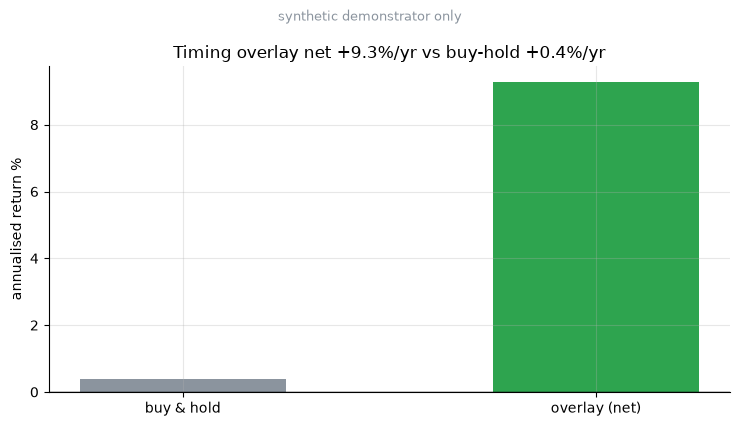

overlay net +9.3%/yr vs buy-hold +0.4%/yr (net excess +8.9%/yr, IR 0.65)


In [3]:
ov = st.overlay_backtest(PANEL, allow_short=False, cost_bps=5.0)
fig, ax = plt.subplots(figsize=(7.5, 4.3))
ax.bar(['buy & hold','overlay (net)'], [ov['buyhold_ann']*100, ov['overlay_net_ann']*100],
       color=[GREY, GREEN], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('annualised return %')
ax.set_title(f'Timing overlay net +{ov["overlay_net_ann"]*100:.1f}%/yr vs buy-hold +{ov["buyhold_ann"]*100:.1f}%/yr')
fig.suptitle('synthetic demonstrator only', fontsize=9, color=GREY)
plt.tight_layout(); plt.show()
print(f'overlay net {ov["overlay_net_ann"]*100:+.1f}%/yr vs buy-hold {ov["buyhold_ann"]*100:+.1f}%/yr '
      f'(net excess {ov["net_excess_ann"]*100:+.1f}%/yr, IR {ov["net_excess_ir"]:.2f})')

On the planted world the overlay adds about **+8.9%/yr** net of costs. Nice — but remember, **this is the synthetic demo**. There is no real seated-diners tape, so this edge is a picture of *what the machine can detect*, not a tradable result.

## 5 · The verdict

- **Signal — Weak.** The idea is plausible and the engine catches a real nowcast cleanly (*t* +4.49 on the planted world, flat at the null). But with **no real tape** it can't clear the bar for a confirmed (**Real**) signal — capped at **Weak**.
- **Tradability — Mirage.** No free, license-able, reproducible seated-diners feed → nothing to actually trade. The edge above lives only in the synthetic world.

## 6 · Could you actually trade it?

No — and the reason is data, not maths. OpenTable's seated-diners dashboard was a **moving web widget** that got restated and then taken down, and it only ever covered the pandemic recovery — a single, weird, non-repeating episode. You can't download a clean multi-year history, so you can't backtest it honestly, let alone run it live. A signal you can't reproduce is a signal you can't trade.

## 7 · Going further 🚪

- **Same pattern, other collectibles/alt-data.** The desk's [273 Lego-Returns](../../273-lego-returns/), [275 Whisky-Cask](../../275-whisky-cask/) and [276 Sneaker-Resale](../../276-sneaker-resale/) are the same 'no free real data → prove the machine on a synthetic world' move.
- **If you have the data.** Got a licensed, point-in-time reservations or foot-traffic panel? Fork this, feed it a real tape, and see whether the predictive *t* clears 2 out of sample — the only way this becomes a **Real** signal.

*The engine is ready; it just needs a real tape that, for free, doesn't exist.*